Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap


Preprocessing & Metrics

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve, roc_curve, auc
from imblearn.over_sampling import SMOTE


Models

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


Read dataset

In [4]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
print(df.head)

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


 DATA CLEANING & INITIAL DROP

In [10]:
df.drop('customerID', axis=1, inplace=True) # ID is useless for prediction
duplicates=df.duplicated().sum()
print("duplcates rows:",duplicates)
df.drop_duplicates(inplace=True)


duplcates rows: 22


EDA (EXPLORATORY DATA ANALYSIS)

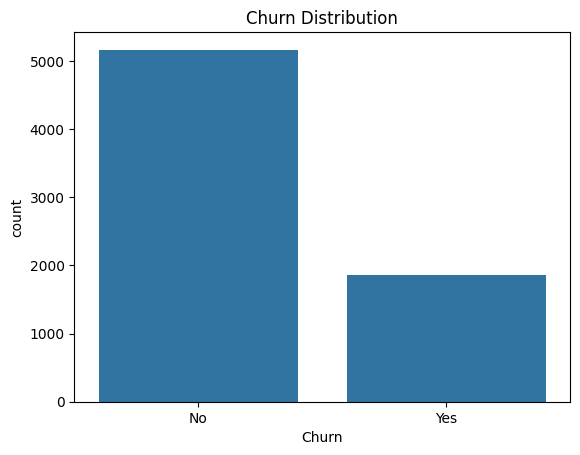

In [11]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


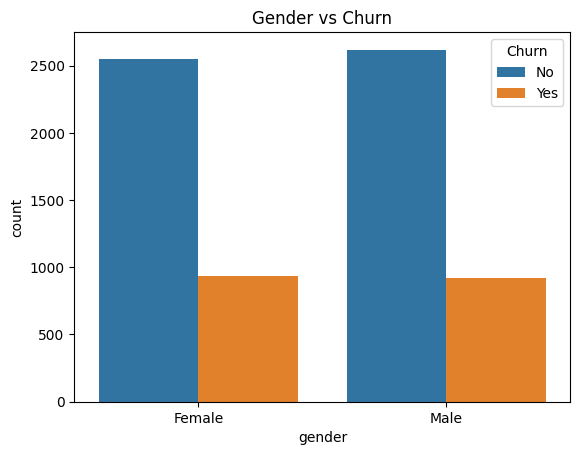

In [12]:
# Gender vs Churn
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

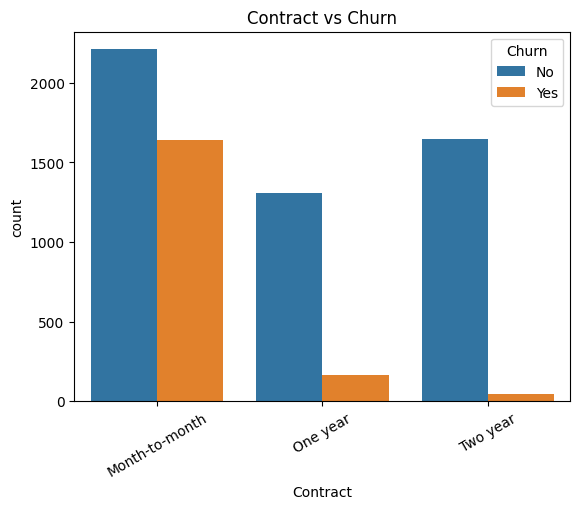

In [13]:
# Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Contract vs Churn")
plt.show()

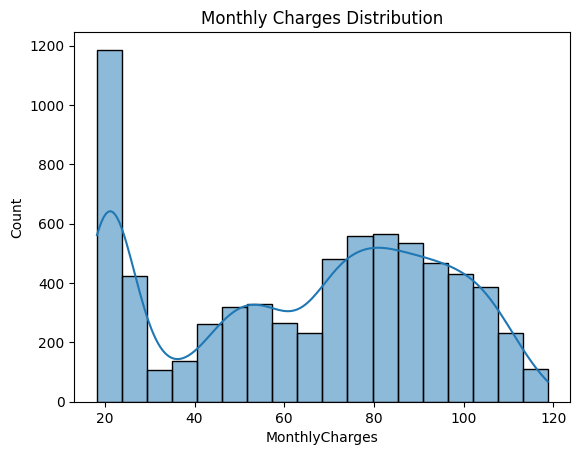

In [14]:
# Monthly Charges distribution
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()


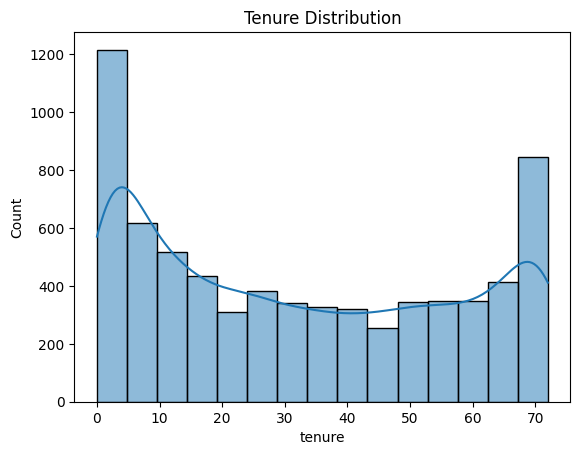

In [15]:
# Tenure distribution
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()


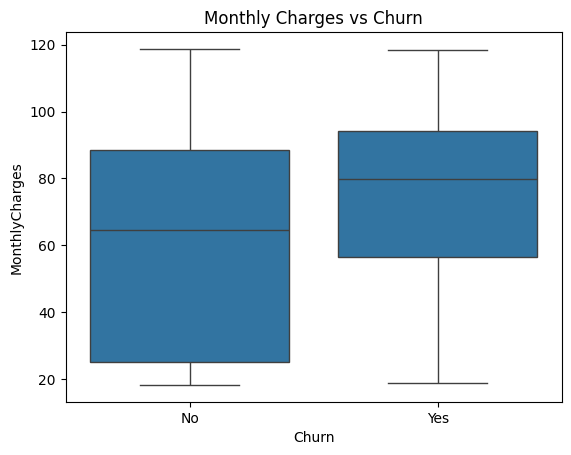

In [16]:
# Boxplot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


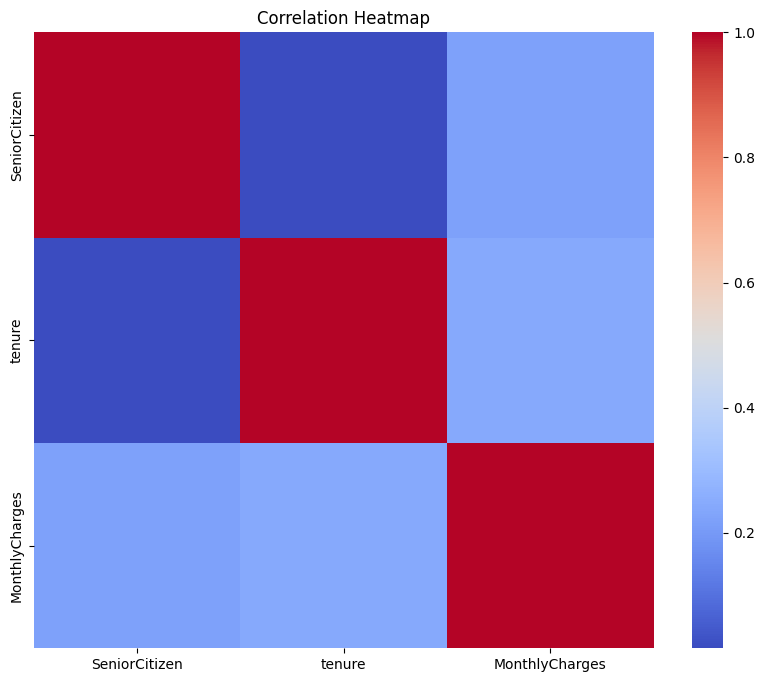

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Convert TotalCharges to numeric and handle the ~11 empty string rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encode Target as binary
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

FEATURE ENCODING (Before Split for Consistency)

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

STRATIFIED SPLIT (Anti-Leakage)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

SCALING (Fit on Train ONLY)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use train mean/std to scale test

BALANCING (SMOTE on Scaled Train ONLY)

In [22]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced Training Set: {np.bincount(y_train_res)}")

Balanced Training Set: [4122 4122]


 MODELING WITH HYPERPARAMETER TUNING

In [23]:
# We use GridSearchCV to optimize for 'f1' or 'recall'
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=3, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train_res, y_train_res)

best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test_scaled)


 BUSINESS-CENTRIC EVALUATION


--- Optimized Random Forest Results ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1031
           1       0.60      0.57      0.58       371

    accuracy                           0.78      1402
   macro avg       0.72      0.72      0.72      1402
weighted avg       0.78      0.78      0.78      1402



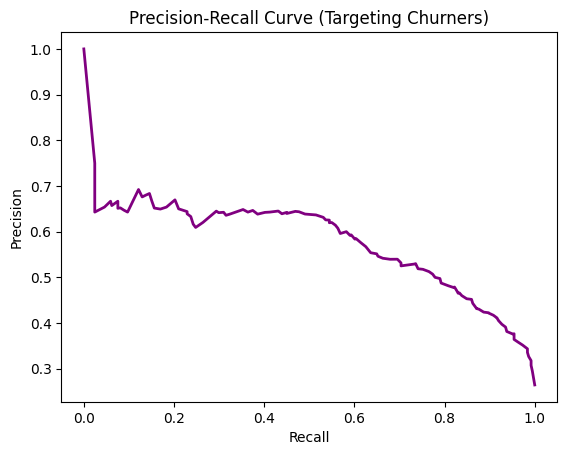

In [24]:
print("\n--- Optimized Random Forest Results ---")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve (Crucial for Imbalanced Churn Data)
precision, recall, _ = precision_recall_curve(y_test, best_rf.predict_proba(X_test_scaled)[:,1])
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Targeting Churners)')
plt.show()


MACHINE LEARNING MODELS

In [25]:
import warnings
warnings.filterwarnings("ignore")
models = {
    "Logistic	Regression":	LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))




Logistic	Regression
[[932  99]
 [171 200]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402


Decision Tree
[[929 102]
 [203 168]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1031
           1       0.62      0.45      0.52       371

    accuracy                           0.78      1402
   macro avg       0.72      0.68      0.69      1402
weighted avg       0.77      0.78      0.77      1402


Random Forest
[[936  95]
 [198 173]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1031
           1       0.65      0.47      0.54       371

    accuracy                           0.79      1402
   macro

MODEL COMPARISON PLOT

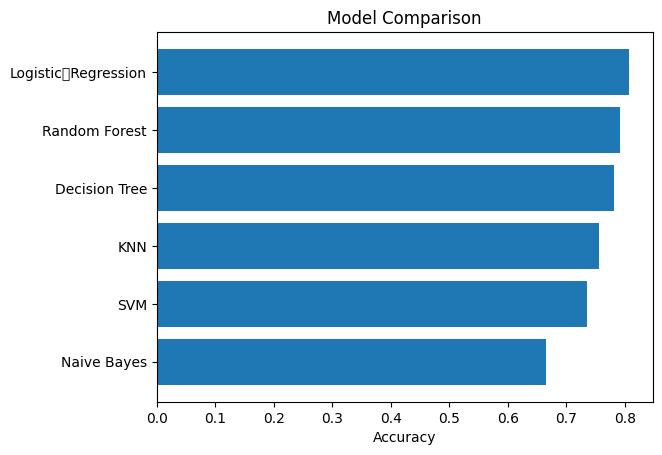

In [26]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df.sort_values(by='Accuracy', inplace=True)

plt.barh(results_df['Model'], results_df['Accuracy'])
plt.title("Model Comparison")
plt.xlabel("Accuracy")
plt.show()

DECISION TREE VISUALIZATION

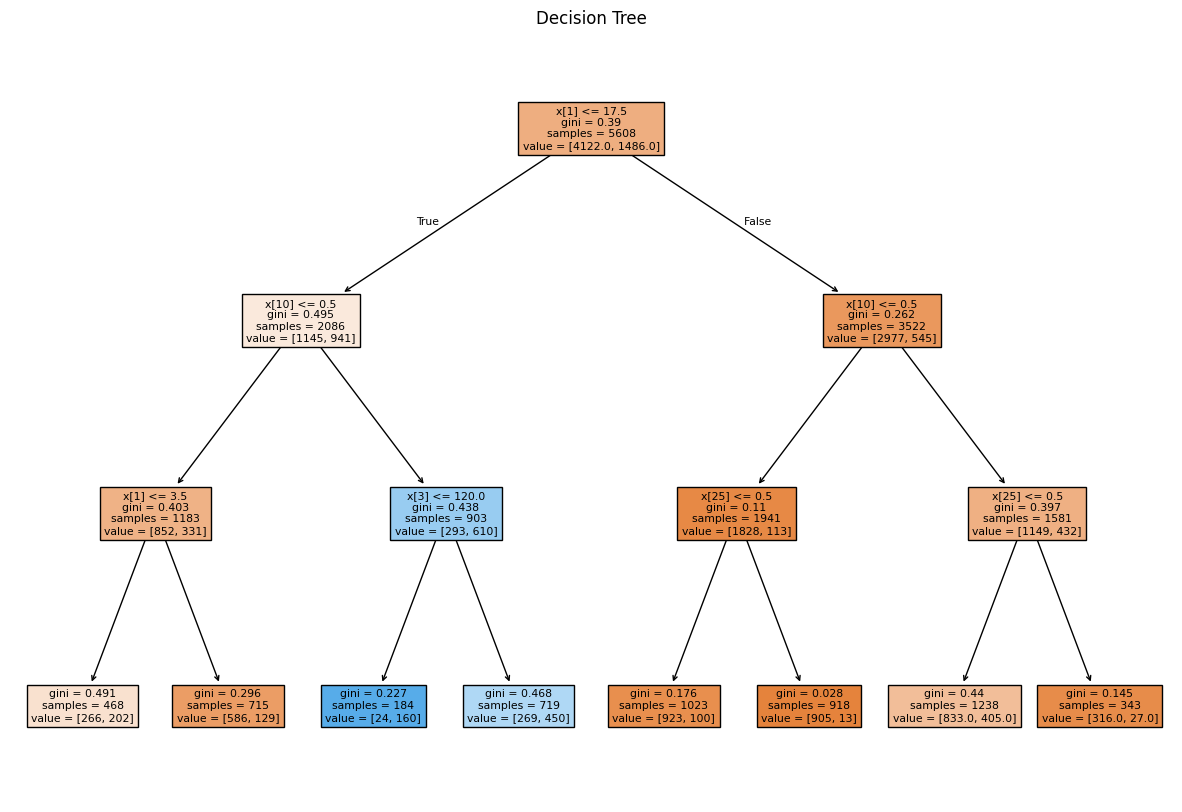

In [27]:
plt.figure(figsize=(15,10))
plot_tree(DecisionTreeClassifier(max_depth=3).fit(X_train, y_train), filled=True)
plt.title("Decision Tree")
plt.show()

Confusion matrix and ROC curve

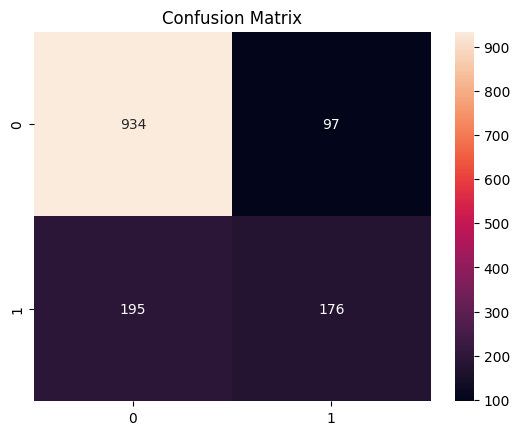

In [29]:
# Confusion matrix heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()



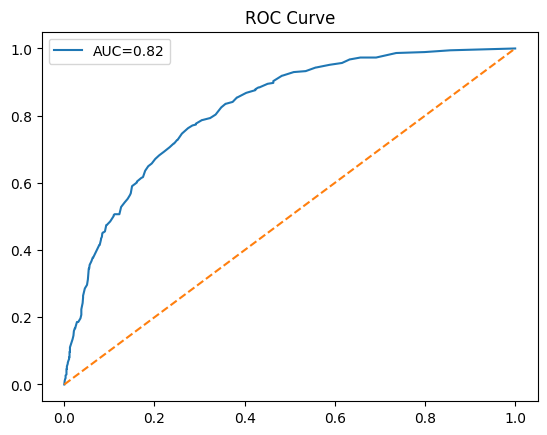

In [30]:
# ROC Curve
probs = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

DEEP LEARNING (ANN)



In [31]:
import warnings
warnings.filterwarnings("ignore")
ann = Sequential()
ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=10, batch_size=32)

ann_pred = (ann.predict(X_test) > 0.5).astype(int)

print("\nANN RESULTS")
print(confusion_matrix(y_test, ann_pred))
print(classification_report(y_test, ann_pred))


Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7193 - loss: 1.2368
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7600 - loss: 0.5801
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7580 - loss: 0.5989
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7764 - loss: 0.5006
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7643 - loss: 0.6071
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7712 - loss: 0.5439
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7650 - loss: 0.6374
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7700 - loss: 0.5557
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7784 - loss: 0.5325
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7769 - loss: 0.5324
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

ANN RESULTS
[[914 117]
 [162 209]]
              precision    recall  f1-score   support

         

INTERPRETABILITY (SHAP) - REFINED

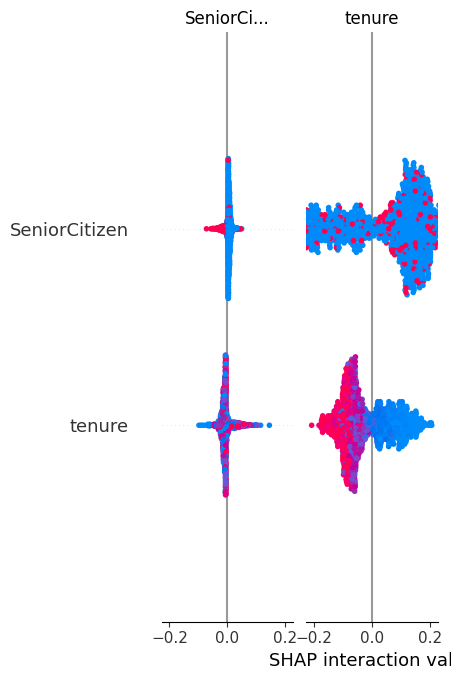

In [32]:
# 1. Initialize the explainer with the model
explainer = shap.TreeExplainer(best_rf)

# 2. Calculate SHAP values for the SCALED test set
# This ensures the model sees the data format it was trained on
shap_values = explainer.shap_values(X_test_scaled)

# 3. Check the shape of shap_values (Debug if necessary)
# For binary classification, shap_values is often a list [class_0, class_1]
# We want class_1 (Churners)
if isinstance(shap_values, list):
    display_shap = shap_values[1]
else:
    display_shap = shap_values

# 4. Generate the plot
# We use X_test_scaled for the data, but X.columns for the readable labels
shap.summary_plot(
    display_shap,
    X_test_scaled,
    feature_names=X.columns
)